In [2]:
import numpy as np
import pandas as pd
from pylab import *
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from pylab import *
from sequana import FastA
import tensorflow as tf
from tensorflow.keras import layers, models
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import random
from collections import defaultdict
from sklearn.metrics import classification_report


In [2]:
centromeres = pd.read_csv("../../output/estimation/major/Major.csv")
centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}


In [3]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

In [3]:
def one_hot_encoding(x):
    if x == 'A':
        return np.array([1,0,0,0])
    elif x == 'C':
        return np.array([0,1,0,0])
    elif x == 'G':
        return np.array([0,0,1,0])
    elif x == 'T':
        return np.array([0,0,0,1])
    else:
        return np.array([0,0,0,0])
        

In [4]:
SIZE=3000

In [4]:
def get_true_positive(centromeres_,f_,size=3000):
    data = []
    for chrom in range(1,36+1):
        start, stop = centromeres_[str(chrom)]
        if f_.names[0] == "1":
            seq = f_.sequences[f_.names.index(str(chrom))]
        else:
            seq = f_.sequences[chrom-1]

        if stop-start != 3000:
            stop = start + size
        # flip to get more positives
        data.append([one_hot_encoding(x) for x in seq[start:stop]])
        data.append([one_hot_encoding(x) for x in seq[start:stop][::-1]])
        

    return data


In [5]:

##################################### WARNING #############################################
############################### REMOVE FALSE NEGATIVE (centromeres) #######################

def get_true_negatives(centromeres_,lengths_,f_,N=1000,size=3000,seed=42):
    data = []
    positions = defaultdict(list)

    # get the random combos first
    for i in tqdm(range(N)):
        chrom = random.randint(1,36)
        if f_.names[0] == "1":
            N = lengths_[str(chrom)]
        else:
            N = lengths_[chrom-1]
        pos = random.randint(1, N-size)
        start, stop = centromeres_[str(chrom)]
        if pos>start and pos<stop:
            pass # this is a centromeres_ so not a negative
        else:
            positions[chrom].append(pos)
        if i == 0:
            print(chrom)
            print(pos)
            print("########")
        
        
    for chrom in tqdm(positions.keys()):
        if f_.names[0] == "1":
            seq = f_.sequences[f_.names.index(str(chrom))]
        else:
            seq = f_.sequences[chrom-1]
        for position in positions[chrom]:
            data.append([one_hot_encoding(x) for x in seq[position:position+size]])
    return data

    #negatives = get_true_negatives(N=10000, size=SIZE)

In [6]:
X_neg = []
X_pos = []
datas =     [["../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta","../../output/estimation/major/Major.csv"],
            ["../../data/Fasta/genome.fasta","../../output/estimation/donovani/donovani_genome.csv"],
           ["../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta","../../output/estimation/martiniquensis.csv"],
           ["../../data/Fasta/genomes/Larabica/ragtag.scaffold.fasta","../../output/estimation/arabica.csv"],
           ["../../data/Fasta/genomes/Laethiopica/ragtag.scaffold.fasta","../../output/estimation/aethiopica.csv"],
           ["../../data/Fasta/genomes/Ltropica/LtropicaRef_genome.fasta","../../output/estimation/tropica.csv"],
           ["../../data/Fasta/genomes/Linfantum/TriTrypDB-68_LinfantumJPCM5_Genome.fasta","../../output/estimation/infantum.csv"],
           ["../../data/Fasta/genomes/Ltarentolae/ragtag.scaffold.fasta","../../output/estimation/tarentolae.csv"],
           ["../../data/Fasta/genomes/Lorientalis/ragtag.scaffold.fasta","../../output/estimation/orientalis.csv"]]
random.seed(3)

for data in datas:
    f = FastA(data[0])
    centromeres = pd.read_csv(data[1])
    centromeres = {
        str(row['Chromosome']): (row['start'], row['end'])
        for _, row in centromeres.iterrows()
    }

    X_pos.extend(get_true_positive(centromeres,f,SIZE))
    if f.names[0] == "1":
        lengths = f.get_lengths_as_dict()
    else:
        lengths = list(f.get_lengths_as_dict().values())
    X_neg.extend(get_true_negatives(centromeres,lengths,f,N=2500, size=SIZE,seed=1))
print(len(X_neg))
print(len(X_pos))

100%|███████████████████████████████████| 2500/2500 [00:00<00:00, 486894.50it/s]


16
621430
########


100%|████████████████████████████████████| 2500/2500 [00:00<00:00, 66085.75it/s]


32
484035
########


100%|███████████████████████████████████| 2500/2500 [00:00<00:00, 420574.36it/s]


...

3
140997
########


100%|███████████████████████████████████| 2500/2500 [00:00<00:00, 478911.17it/s]


33
1083747
########


100%|███████████████████████████████████████████| 36/36 [00:08<00:00,  4.20it/s]

22372
648


In [7]:
print(len(X_pos))

#X_pos = positives
#X_neg = negatives

# Create label arrays
y_pos = [1] * len(X_pos)
y_neg = [0] * len(X_neg)

# Combine and shuffle
X = np.array(X_pos + X_neg)  # shape: (N, 3000, 4)
y = np.array(y_pos + y_neg)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


layer_size=32

model = models.Sequential([
    layers.Input(shape=(SIZE, 4)),
    layers.Conv1D(layer_size,15, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(layer_size*2, 10, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(layer_size, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

seed = 42

tf.random.set_seed(seed)

tf.config.experimental.enable_op_determinism()
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=32,
    class_weight={0: 1, 1: len(y_neg)/len(y_pos)},  # handle imbalance
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)


y_pred = model.predict(X_test) > 0.2
report = classification_report(y_test, y_pred, output_dict=True)

metrics = {
    'f1_score': report['1']['f1-score'],
    'precision': report['1']['precision'],
    'recall': report['1']['recall']
}




648


2025-07-31 10:05:42.482069: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/40


2025-07-31 10:05:43.036398: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1767936000 exceeds 10% of free system memory.
2025-07-31 10:05:43.932418: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1767936000 exceeds 10% of free system memory.
2025-07-31 10:05:44.772691: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapData

576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7774 - loss: 0.9744

...

576/576 ━━━━━━━━━━━━━━━━━━━━ 66s 111ms/step - accuracy: 0.7776 - loss: 0.9738 - val_accuracy: 0.8202 - val_loss: 0.4142
Epoch 2/40
576/576 ━━━━━━━━━━━━━━━━━━━━ 80s 109ms/step - accuracy: 0.9632 - loss: 0.2250 - val_accuracy: 0.8499 - val_loss: 0.3706
Epoch 3/40
576/576 ━━━━━━━━━━━━━━━━━━━━ 84s 113ms/step - accuracy: 0.9716 - loss: 0.1540 - val_accuracy: 0.9674 - val_loss: 0.1027
Epoch 4/40
576/576 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.9811 - loss: 0.1096 - val_accuracy: 0.9859 - val_loss: 0.0525
Epoch 5/40
576/576 ━━━━━━━━━━━━━━━━━━━━ 64s 112ms/step - accuracy: 0.9838 - loss: 0.0746 - val_accuracy: 0.9950 - val_loss: 0.0242
Epoch 6/40
576/576 ━━━━━━━━━━━━━━━━━━━━ 62s 108ms/step - accuracy: 0.9803 - loss: 0.0889 - val_accuracy: 0.9637 - val_loss: 0.1069
Epoch 7/40
576/576 ━━━━━━━━━━━━━━━━━━━━ 63s 109ms/step - accuracy: 0.9879 - loss: 0.0460 - val_accuracy: 0.9928 - val_loss: 0.0304
Epoch 8/40
576/576 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy: 0.9966 - loss: 0.0194 - val

2025-07-31 10:21:01.165865: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 441984000 exceeds 10% of free system memory.


  3/144 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step  

2025-07-31 10:21:01.602958: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


In [8]:
model.save('model_32layer_seed3_all.keras')  # Format HDF5

In [9]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test) > 0.2
print(classification_report(y_test, y_pred))

  5/144 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step

2025-07-31 10:21:15.570769: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4474
           1       0.88      0.97      0.92       130

    accuracy                           1.00      4604
   macro avg       0.94      0.98      0.96      4604
weighted avg       1.00      1.00      1.00      4604



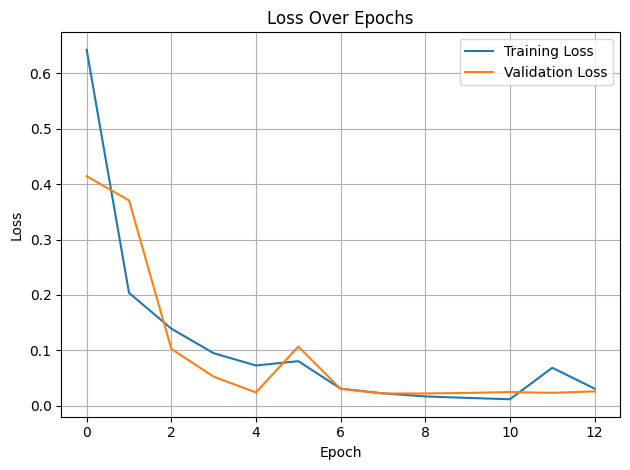

In [10]:
import matplotlib.pyplot as plt


# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


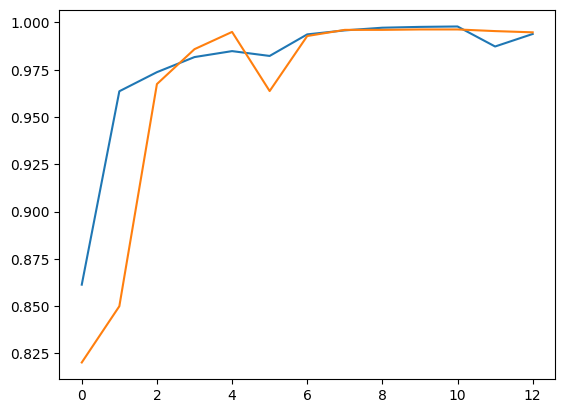

In [11]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')

  5/144 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step

2025-07-31 10:22:11.643199: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step


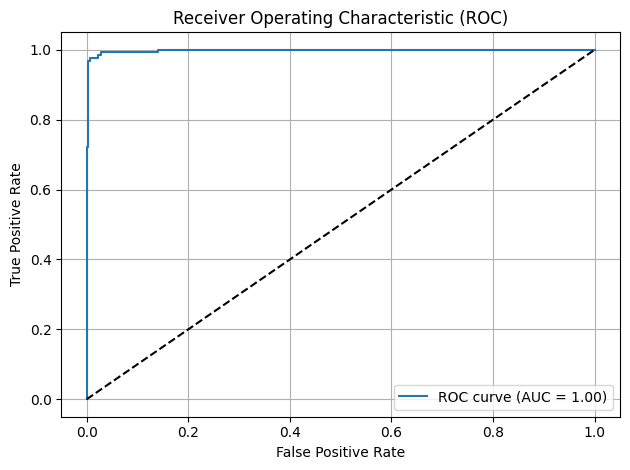

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict(X_test).ravel()  # get raw probabilities

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


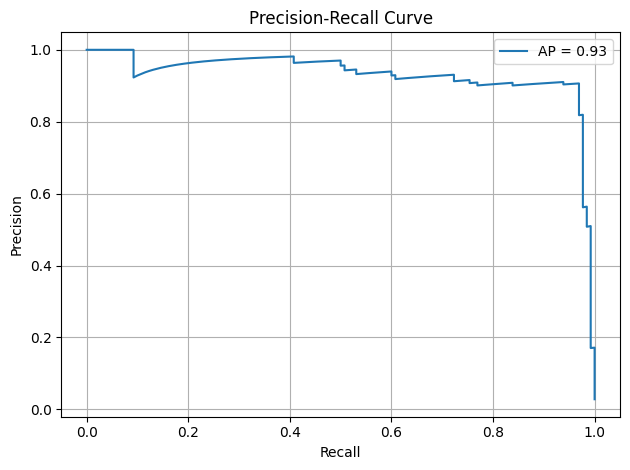

In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, label=f'AP = {avg_prec:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
import numpy as np

def predict_sliding_windows(seq, model, window_size=3000, step=1500):
    
    scores = []
    positions = []

    # Slide through the sequence
    for i in tqdm(range(0, len(seq) - window_size + 1, step)):
        chunk = seq[i:i + window_size]
        
        # One-hot encoded? Already a list of np.array([1,0,0,0]) per base
        # Otherwise, if string-based: encode here
        chunk = [one_hot_encoding(x) for x in chunk]
        X = np.array(chunk).reshape(1, window_size, 4)  # batch of 1
        prob = model.predict(X, verbose=0)[0][0]
        
        scores.append(prob)
        positions.append((i, i + window_size))

    return positions, scores


In [15]:
all_scores = {}
results = {}


100%|█████████████████████████████████████████| 178/178 [00:14<00:00, 12.05it/s]


1 (256500, 259500) 0.99756926


100%|█████████████████████████████████████████| 236/236 [00:18<00:00, 12.49it/s]


2 (265500, 268500) 0.9997639


100%|█████████████████████████████████████████| 255/255 [00:20<00:00, 12.34it/s]


...

34 (300000, 303000) 0.9992473


100%|███████████████████████████████████████| 1392/1392 [02:02<00:00, 11.34it/s]


35 (546000, 549000) 0.9946313


100%|███████████████████████████████████████| 1787/1787 [02:29<00:00, 11.99it/s]


36 (1113000, 1116000) 0.9968279


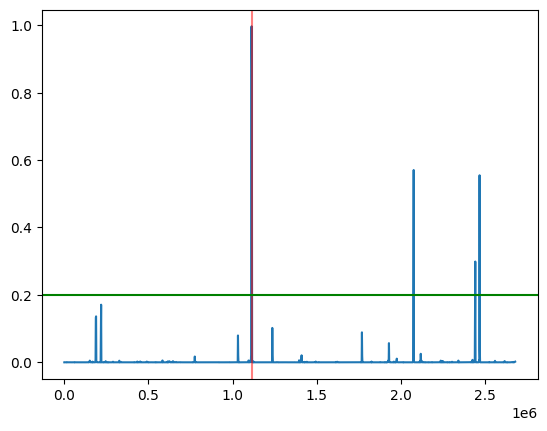

In [16]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")
#f = FastA("../../data/Fasta/genome.fasta")
#f = FastA("../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta")

#centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
#centromeres = pd.read_csv("../../output/estimation/mexicana.csv")

#f = FastA("../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta")
#centromeres = pd.read_csv("../../output/estimation/martiniquensis.csv")
centromeres = pd.read_csv("../../output/estimation/major/Major.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all2/major/CNN1_{chrom}_Lmajor.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)

  0%|                                           | 1/492 [00:00<00:52,  9.42it/s]

ERROR! Session/line number was not unique in database. History logging moved to new session 306


100%|█████████████████████████████████████████| 492/492 [00:41<00:00, 11.80it/s]


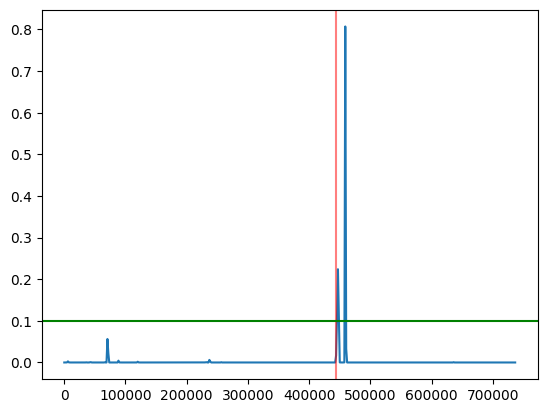

In [20]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

recherche = 18
for chrom in range(recherche,recherche+1):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.1, color='g')


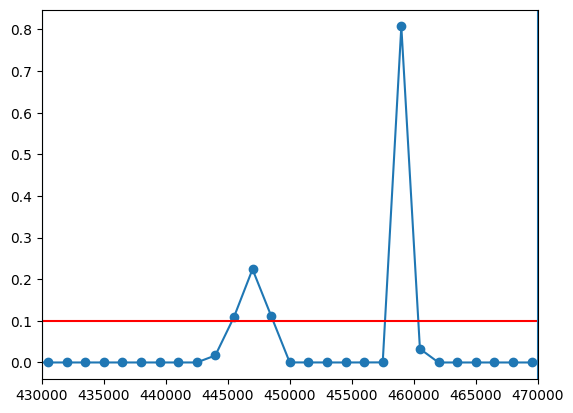

In [23]:
plot([x[0] for  x in positions], scores, 'o-')
xlim([430000,470000])
axhline(0.1, color='r')
axvline(430000)
axvline(470000)

100%|███████████████████████████████████████████| 75/75 [00:06<00:00, 11.99it/s]


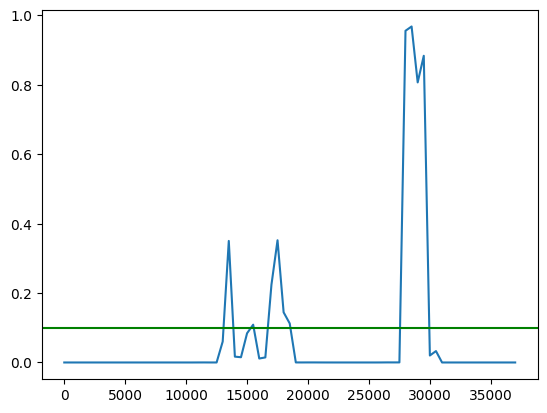

In [26]:
f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")

recherche = 18
for chrom in range(recherche,recherche+1):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        seq = f.sequences[chrom-1]
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    seq = seq[430000:470000]
    positions, scores = predict_sliding_windows(seq, model,SIZE,500)
    _ = plot([x[0] for x in positions], scores)
    axhline(0.1, color='g')

100%|█████████████████████████████████████████| 257/257 [00:22<00:00, 11.41it/s]


1 (271500, 274500) 0.99938595


100%|█████████████████████████████████████████| 271/271 [00:23<00:00, 11.65it/s]


2 (291000, 294000) 0.99979824


100%|█████████████████████████████████████████| 276/276 [00:23<00:00, 11.82it/s]


...

34 (336000, 339000) 0.99984616


100%|███████████████████████████████████████| 1451/1451 [01:59<00:00, 12.11it/s]


35 (616500, 619500) 0.9955725


100%|███████████████████████████████████████| 1896/1896 [02:42<00:00, 11.65it/s]


36 (1209000, 1212000) 0.99148035


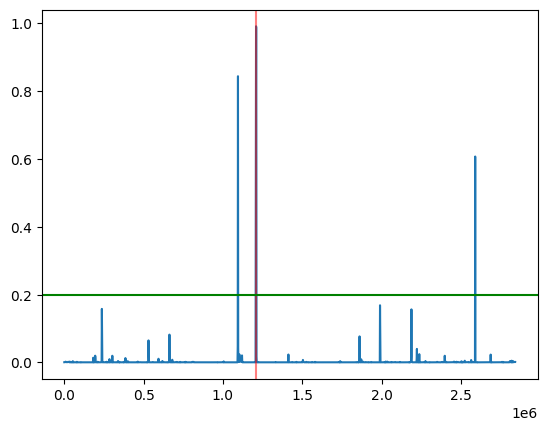

In [18]:

f = FastA("../../data/Fasta/genome.fasta")
#f = FastA("../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta")

centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
#centromeres = pd.read_csv("../../output/estimation/mexicana.csv")

#f = FastA("../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta")
#centromeres = pd.read_csv("../../output/estimation/martiniquensis.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all2/donovani/CNN1_{chrom}_Ldono.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)


100%|█████████████████████████████████████████| 181/181 [00:15<00:00, 11.76it/s]


1 (256500, 259500) 0.9981802


100%|█████████████████████████████████████████| 197/197 [00:16<00:00, 11.74it/s]


2 (234000, 237000) 0.99976325


100%|█████████████████████████████████████████| 249/249 [00:22<00:00, 11.02it/s]


...

34 (303000, 306000) 0.9997419


100%|███████████████████████████████████████| 1311/1311 [01:43<00:00, 12.62it/s]


35 (462000, 465000) 0.9935424


100%|███████████████████████████████████████| 2227/2227 [02:53<00:00, 12.84it/s]


36 (3132000, 3135000) 0.97759306


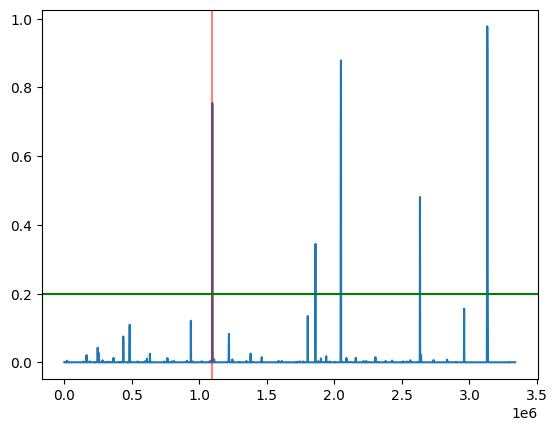

In [19]:

f = FastA("../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta")

#centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")
centromeres = pd.read_csv("../../output/estimation/mexicana.csv")

#f = FastA("../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta")
#centromeres = pd.read_csv("../../output/estimation/martiniquensis.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all2/mexicana/CNN1_{chrom}_Lmexicana.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)

100%|█████████████████████████████████████████| 160/160 [00:12<00:00, 12.73it/s]


1 (82500, 85500) 0.20103714


100%|█████████████████████████████████████████| 246/246 [00:19<00:00, 12.87it/s]


2 (276000, 279000) 0.9982529


100%|█████████████████████████████████████████| 256/256 [00:19<00:00, 12.95it/s]


...

34 (322500, 325500) 0.9850483


100%|███████████████████████████████████████| 1368/1368 [01:49<00:00, 12.49it/s]


35 (504000, 507000) 0.93821484


100%|███████████████████████████████████████| 1804/1804 [02:19<00:00, 12.96it/s]


36 (1152000, 1155000) 0.99452055


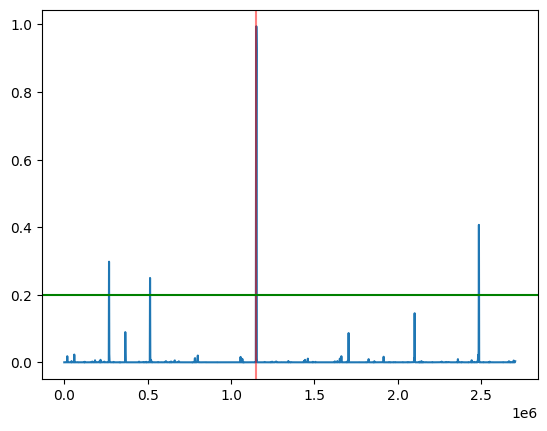

In [20]:



f = FastA("../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta")
centromeres = pd.read_csv("../../output/estimation/martiniquensis.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all2/martiniquensis/CNN1_{chrom}_Lmarti.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)

In [ ]:


f = FastA("../../data/Fasta/genomes/Ltropica/LtropicaRef_genome.fasta")
centromeres = pd.read_csv("../../output/estimation/tropica.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all2/tropicana/CNN1_{chrom}_Ltropicana.png")
    print(chrom, positions[argmax(scores)], max(scores))
    all_scores[chrom] = max(scores)

100%|█████████████████████████████████████████| 190/190 [00:15<00:00, 12.13it/s]


1 (264000, 267000) 0.9968334


100%|█████████████████████████████████████████| 237/237 [00:19<00:00, 12.38it/s]


2 (270000, 273000) 0.9999496


100%|█████████████████████████████████████████| 258/258 [00:20<00:00, 12.56it/s]


...

100%|█████████████████████████████████████████| 573/573 [00:43<00:00, 13.03it/s]


24 (478500, 481500) 0.99742883


100%|█████████████████████████████████████████| 599/599 [00:48<00:00, 12.30it/s]


25 (577500, 580500) 0.9978965


 35%|██████████████▏                          | 246/712 [00:19<00:37, 12.28it/s]

100%|█████████████████████████████████████████| 175/175 [00:11<00:00, 14.62it/s]


1 (253500, 256500) 0.997831


100%|█████████████████████████████████████████| 190/190 [00:13<00:00, 14.41it/s]


2 (235500, 238500) 0.9998469


100%|█████████████████████████████████████████| 259/259 [00:18<00:00, 14.25it/s]


...

34 (475500, 478500) 0.9991146


100%|███████████████████████████████████████| 1317/1317 [01:30<00:00, 14.58it/s]


35 (448500, 451500) 0.99847376


100%|███████████████████████████████████████| 1767/1767 [02:00<00:00, 14.62it/s]


36 (1095000, 1098000) 0.9988233


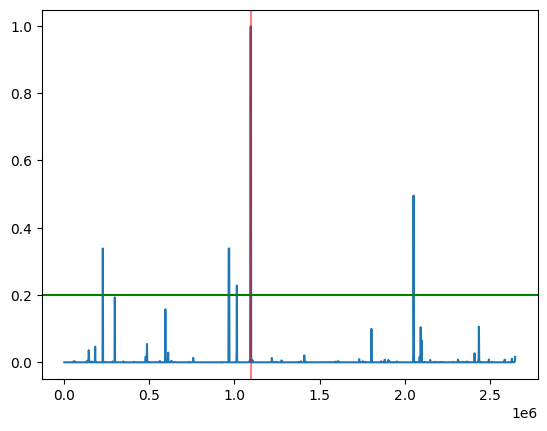

In [7]:


f = FastA("../../data/Fasta/genomes/Larabica/ragtag.scaffold.fasta")
centromeres = pd.read_csv("../../output/estimation/arabica.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}

for chrom in range(1,37):
    #f = FastA("LmajorFriedlin/LmajorFriedlin_genome.fasta")
            
    try:
        #seq = f.sequences[chrom-1]
        seq = f.sequences[f.names.index(str(chrom))]

    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all2/arabica/CNN1_{chrom}_Larabica.png")
    print(chrom, positions[argmax(scores)], max(scores))


In [1]:
from tensorflow.keras.models import load_model

model = load_model('model_32layer_seed3_all.keras')


2025-07-31 12:41:01.206024: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-31 12:41:01.210247: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-31 12:41:01.223239: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753958461.243514 1583385 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753958461.249618 1583385 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753958461.265013 1583385 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin